In [2]:
import pandas as pd
import numpy as np

In [3]:
import pandas as pd
data = pd.read_csv("diabetes.csv")

In [4]:
data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
X = data.iloc[:,:-1]
y = data.iloc[:,-1]

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense,Dropout

In [43]:
def build_model(hp):
  model = Sequential()

  model.add(Dense(units=hp.Int('No_Node',min_value=2,max_value=32),
                  activation = hp.Choice('activation',values=('relu','tanh','sigmoid')),
                  input_dim = 8))

  for i in range(hp.Int('num_layers',min_value=1,max_value=10)):
    model.add(Dense(units=hp.Int('No_Node',min_value=2,max_value=32),
                  activation = hp.Choice('activation',values=('relu','tanh','sigmoid'))))
    model.add(Dropout(hp.Choice('Dropout',values=[0.1,0.2,0.3,0.4,0.5])))

  model.add(Dense(1,activation='sigmoid'))

  model.compile(optimizer=hp.Choice('optimizer',values=['adam','rmsprop','adagrad','sgd','adamax']),
                loss='binary_crossentropy',
                metrics=['accuracy'])
  return model

In [44]:
import keras_tuner as kt

In [45]:
tuner = kt.RandomSearch(
    build_model,
    objective = 'val_accuracy',
    max_trials = 15,
    executions_per_trial = 3,
    directory = 'project',
    project_name = 'diabetes'
)

Reloading Tuner from project/diabetes/tuner0.json


In [46]:
tuner.search(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

Trial 15 Complete [00h 00m 22s]
val_accuracy: 0.677489181359609

Best val_accuracy So Far: 0.7575757503509521
Total elapsed time: 00h 15m 06s


In [47]:
best_hp = tuner.get_best_hyperparameters(1)[0]

In [ ]:
print("\nBEST PARAMETERS")
print("------------------")
print("Layers :", best_hp.get('num_layers'))
print("Activation :", best_hp.get('activation'))
print("Optimizer :", best_hp.get('optimizer'))

for i in range(best_hp.get('num_layers')):
    print(
        f"Units Layer {i+1}:",
        best_hp.get('No_Node')
    )


BEST PARAMETERS
------------------
Layers : 6
Activation : tanh
Optimizer : adamax
Units Layer 1: 16
Units Layer 2: 16
Units Layer 3: 16
Units Layer 4: 16
Units Layer 5: 16
Units Layer 6: 16


In [34]:
best_hp

In [49]:
best_model = tuner.get_best_models(1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamax', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [57]:
history = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    initial_epoch=10,
    batch_size=32,
    verbose=1,
    epochs=65
)


Epoch 11/65
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7834 - loss: 0.4905 - val_accuracy: 0.7403 - val_loss: 0.5181
Epoch 12/65
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7866 - loss: 0.4563 - val_accuracy: 0.7403 - val_loss: 0.5134
Epoch 13/65
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7590 - loss: 0.4911 - val_accuracy: 0.7403 - val_loss: 0.5141
Epoch 14/65
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7785 - loss: 0.4814 - val_accuracy: 0.7468 - val_loss: 0.5141
Epoch 15/65
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7818 - loss: 0.4806 - val_accuracy: 0.7403 - val_loss: 0.5144
Epoch 16/65
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7866 - loss: 0.4714 - val_accuracy: 0.7403 - val_loss: 0.5157
Epoch 17/65
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7606 - loss: 0.5175 - val_accuracy: 0.7403 - val_loss: 0.5156
Epoch 18/65
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7606 - loss: 0.4995 - val_accuracy: 0.7403 

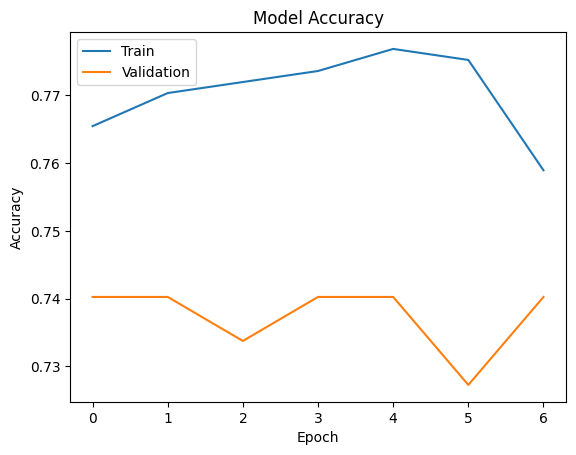

In [55]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()